# Netflix Data Analytics and Recommendation Engine

# Phase 1: Data Cleaning & Preprocessing

### Project Objectives:
* Load the raw Netflix dataset and inspect its structure.
* Handle missing values (`NaN`) in critical metadata fields (`director`, `cast`, `country`).
* Perform feature engineering by converting date strings to standard datetime formats.
* Extract new temporal columns (`year_added`, `month_added`) for deep-dive analysis.
* Reset the DataFrame index to prevent layout gaps during machine learning loops.


In [2]:
import pandas as pd
df = pd.read_csv("netflix_titles.csv") # Load and read csv
print(df)

     show_id     type                  title         director  \
0         s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1         s2  TV Show          Blood & Water              NaN   
2         s3  TV Show              Ganglands  Julien Leclercq   
3         s4  TV Show  Jailbirds New Orleans              NaN   
4         s5  TV Show           Kota Factory              NaN   
...      ...      ...                    ...              ...   
8802   s8803    Movie                 Zodiac    David Fincher   
8803   s8804  TV Show            Zombie Dumb              NaN   
8804   s8805    Movie             Zombieland  Ruben Fleischer   
8805   s8806    Movie                   Zoom     Peter Hewitt   
8806   s8807    Movie                 Zubaan      Mozez Singh   

                                                   cast        country  \
0                                                   NaN  United States   
1     Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa 

In [3]:
# Shape shows the rows and columns count of the dataset
print("Dataset shape", df.shape)

Dataset shape (8807, 12)


In [5]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [8]:
pip install scikit-learn

   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/8.9 MB 5.0 MB/s eta 0:00:02
   ---------- ----------------------------- 2.4/8.9 MB 5.4 MB/s eta 0:00:02
   ---------------- ----------------------- 3.7/8.9 MB 5.7 MB/s eta 0:00:01
   ----------------------- ---------------- 5.2/8.9 MB 6.0 MB/s eta 0:00:01
   ---------------------------- ----------- 6.3/8.9 MB 5.8 MB/s eta 0:00:01
   ---------------------------------- ----- 7.6/8.9 MB 5.9 MB/s eta 0:00:01
   -------------------------------------- - 8.7/8.9 MB 6.0 MB/s eta 0:00:01
   ---------------------------------------- 8.9/8.9 MB 5.6 MB/s  0:00:01
   ---------------------------------------- 0.0/41.3 MB ? eta -:--:--
   -- ------------------------------------- 2.4/41.3 MB 11.2 MB/s eta 0:00:04
   ---- --------------------------------


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Load dataset
df = pd.read_csv("netflix_titles.csv")

# Handle missing values"  
df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Unknown")
df["country"] = df["country"].fillna(df["country"].mode()[0])
df.dropna(subset=["date_added", "rating", "duration"], inplace=True)

# Format dates and extract year/month
df["date_added"] = df["date_added"].str.strip()
df["date_added"] = pd.to_datetime(df["date_added"], format="%B %d, %Y")
df["year_added"] = df["date_added"].dt.year.astype(int)
df["month_added"] = df["date_added"].dt.month_name()

df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,September
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,September
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021,September
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,United States,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021,September
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021,September


# Phase 2: Exploratory Data Analysis (EDA)

### Objectives:
* Analyze the proportional distribution between Movies and TV Shows using structural plots.
* Track the year-over-year content acquisition velocity to map Netflix's growth pattern.
* Unnest comma-separated text data to successfully isolate, rank, and view the top 10 genres dominating the platform.


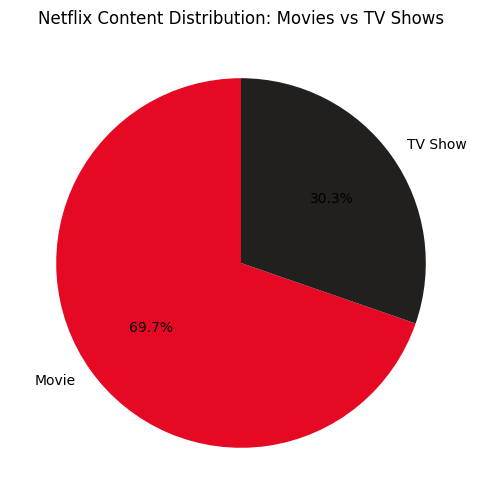

In [8]:
# Create pie chart for Movies vs TV Shows
plt.figure(figsize=(6, 6))
df["type"].value_counts().plot(
    kind="pie", autopct="%1.1f%%", colors=["#E50924", "#221F1F"], startangle=90
)
plt.title("Netflix Content Distribution: Movies vs TV Shows")
plt.ylabel("")
plt.show()


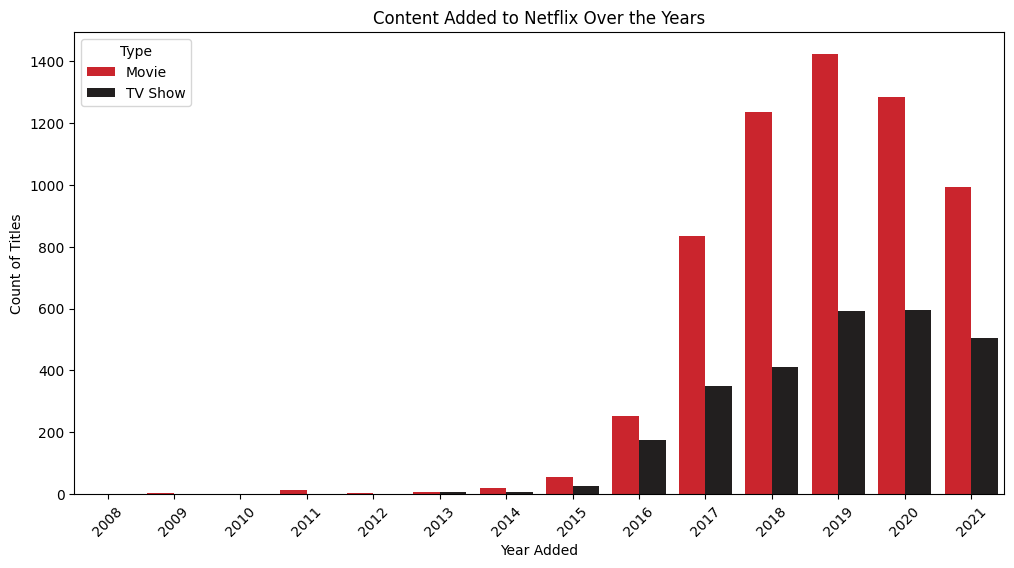

In [9]:
# Plot growth of content additions
plt.figure(figsize=(12, 6))
sns.countplot(
    data=df, x="year_added", hue="type", palette=["#E50914", "#221F1F"]
)
plt.title("Content Added to Netflix Over the Years")
plt.xlabel("Year Added")
plt.ylabel("Count of Titles")
plt.xticks(rotation=45)
plt.legend(title="Type")
plt.show()

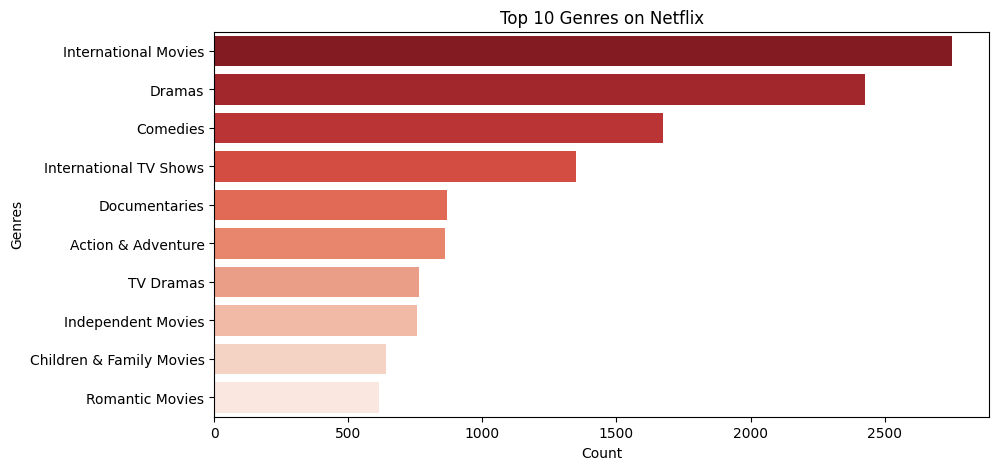

In [19]:
# Unnest and count genres
genres = df["listed_in"].str.split(", ").explode()

plt.figure(figsize=(10, 5))

# Fixed: assign y variable to the hue, legend=False
sns.barplot(
    x=genres.value_counts().head(10).values,
    y=genres.value_counts().head(10).index,
    hue=genres.value_counts().head(10).index,
    palette="Reds_r",
    legend=False,
)

plt.title("Top 10 Genres on Netflix")
plt.xlabel("Count")
plt.ylabel("Genres")
plt.show()



# Phase 3: Text Vectorization & Recommendation Engine

### Objectives:
* Extract textual patterns from the asset `description` array.
* Deploy natural language processing via `TfidfVectorizer` to remove stop words and convert strings into numeric vectors.
* Calculate mathematical alignment across metadata profiles using `Cosine Similarity` matrices.
* Construct an automated python pipeline (`get_recommendations`) to dynamically display the top 5 closest contextual recommendations.


In [11]:
# Initialize TF-IDF Vectorizer to analyze plot descriptions
tfidf = TfidfVectorizer(stop_words="english")
tfidf_matrix = tfidf.fit_transform(df["description"])

# Compute similarity scores between all titles
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)


# Recommendation function
def get_recommendations(title, cosine_sim=cosine_sim):
    # Find index of the matching title
    if title not in df["title"].values:
        return "Title not found in dataset."

    idx = df[df["title"] == title].index[0]

    # Get pairwise similarity scores
    sim_scores = list(enumerate(cosine_sim[idx]))

    # Sort based on similarity scores
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # Get top 5 most similar titles (excluding itself)
    sim_scores = sim_scores[1:6]
    movie_indices = [i[0] for i in sim_scores]

    return df.iloc[movie_indices][["title", "type", "listed_in", "description"]]


# Test the recommender system
get_recommendations("Stranger Things")


,title,type,listed_in,description
4733,Rowdy Rathore,Movie,"Action & Adventure, Comedies, International Mo...",A con man uncovers a deadly secret and must sa...
1240,Safe Haven,Movie,"Dramas, Romantic Movies",When a mysterious woman arrives in a small Nor...
1487,Sakho & Mangane,TV Show,"Crime TV Shows, International TV Shows, TV Dramas",A by-the-book police captain and a brash young...
8198,The Autopsy of Jane Doe,Movie,"Horror Movies, Independent Movies, Thrillers",A father-son team of small-town coroners perfo...
2419,Big Stone Gap,Movie,"Comedies, Romantic Movies",A single middle-aged woman who has lived her w...


In [12]:
print(df.shape)

(8790, 14)


In [18]:
# 1. First, DataFrame index was resetted for fix loop
df = df.reset_index(drop=True)

# 2. Re-initialize TF-IDF Vectorizer
tfidf = TfidfVectorizer(stop_words="english")
tfidf_matrix = tfidf.fit_transform(df["description"])

# 3. Compute similarity scores with fresh index
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)


# 4. Updated Recommendation function
def get_recommendations(title, cosine_sim=cosine_sim):
    if title not in df["title"].values:
        return "Title not found in dataset."

    # To take index match perfectly, We are using .values[0]
    idx = df[df["title"] == title].index[0]

    # Get pairwise similarity scores
    sim_scores = list(enumerate(cosine_sim[idx]))

    # Sort based on similarity scores (sort using x[1])
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # Get top 5 most similar titles (excluding itself)
    sim_scores = sim_scores[1:6]
    movie_indices = [i[0] for i in sim_scores]

    return df.iloc[movie_indices][["title", "type", "listed_in", "description"]]


# Now test again!
get_recommendations("Zombieland")


,title,type,listed_in,description
8619,True to the Game,Movie,Dramas,When a drug kingpin looking to go legit falls ...
1841,The Last Kids on Earth,TV Show,"Kids' TV, TV Comedies","When zombies and monsters invade his hometown,..."
1631,Rust Creek,Movie,Thrillers,A wrong turn in the woods becomes a fight for ...
8095,Submission,Movie,"Action & Adventure, Dramas","After a near-death trip home, a Marine looking..."
2091,The Bridge Curse,Movie,"Horror Movies, International Movies, Thrillers",A group of university students decides to test...


In [21]:
# Now, cleaned advanced table will save as new dataset in our personal computer.
df.to_csv("netflix_cleaned_final.csv", index=False)
